In [ ]:
# 安裝 TensorFlow Datasets 最新 nightly 版（每天更新，通常包含最新資料集與 bug 修正）
!pip install -q tfds-nightly

# 下面這行目前先註解掉：
# 如果你在執行 transformer.ipynb 時遇到 matplotlib 畫圖錯誤，可以考慮降版本到 3.2.2
# 這是因為新版 matplotlib 對 ticks 數量的檢查變嚴格，舊版程式碼可能不相容
# !pip install matplotlib==3.2.2


In [ ]:
# 匯入 TensorFlow Datasets，用來下載與管理常見開放資料集
import tensorflow_datasets as tfds

# 匯入 TensorFlow 主程式庫，這裡會用來建模、訓練與資料處理
import tensorflow as tf

# 匯入 time 套件，用來記錄程式執行時間（例如訓練花多久）
import time

# 匯入 numpy，進行數值運算、矩陣處理
import numpy as np

# 匯入 matplotlib，繪製訓練曲線、預測結果等圖表
import matplotlib.pyplot as plt


c:\Users\jason\anaconda3\envs\DL\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup input pipeline

Use [TFDS](https://www.tensorflow.org/datasets) to load the [Portugese-English translation dataset](https://github.com/neulab/word-embeddings-for-nmt) from the [TED Talks Open Translation Project](https://www.ted.com/participate/translate).

This dataset contains approximately 50000 training examples, 1100 validation examples, and 2000 test examples.

In [ ]:
# 從 TensorFlow Datasets 下載 'ted_hrlr_translate/pt_to_en' 這個資料集
# 這是一個葡萄牙文 (pt) → 英文 (en) 的翻譯資料集，常用於訓練 Transformer 模型

examples, metadata = tfds.load(
    'ted_hrlr_translate/pt_to_en',  # 資料集名稱
    with_info=True,                 # 回傳包含資料集 meta 資訊（如樣本數、特徵說明）
    as_supervised=True              # 直接以 (input, target) 格式回傳，方便訓練
)

# 將訓練集與驗證集分開，方便後續模型訓練與評估
train_examples, val_examples = examples['train'], examples['validation']


Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...: 100%|██████████| 1/1 [01:24<00:00, 80.96s/ url]

Dl Completed...: 100%|██████████| 1/1 [01:25<00:00, 85.55s/ url]


Dataset ted_hrlr_translate downloaded and prepared to C:\Users\jason\tensorflow_datasets\ted_hrlr_translate\pt_to_en\1.0.0. Subsequent calls will reuse this data.


Create a custom subwords tokenizer from the training dataset.

In [ ]:
# 建立英文 (en) 子詞分詞器 (SubwordTextEncoder)
# build_from_corpus 會從訓練資料中自動學習常見的子詞單位 (subword units)
# 例如：將 frequent word piece like 'ing', 'tion' 進行自動切分，提高訓練穩定性與 OOV 處理能力
# target_vocab_size=2**13 → 詞彙表大小約 8192

tokenizer_en = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(
    (en.numpy() for pt, en in train_examples),  # 從訓練資料英文部份擷取語料
    target_vocab_size=2**13
)

# 建立葡萄牙文 (pt) 子詞分詞器
tokenizer_pt = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(
    (pt.numpy() for pt, en in train_examples),  # 從訓練資料葡萄牙文部份擷取語料
    target_vocab_size=2**13
)


In [ ]:
# 測試字串
sample_string = 'Transformer is awesome.'

# 使用剛剛訓練好的英文子詞分詞器進行編碼（encode）
# 會將整個句子轉換成子詞 ID 序列
tokenized_string = tokenizer_en.encode(sample_string)
print('Tokenized string is {}'.format(tokenized_string))

# 將子詞 ID 序列解碼（decode）回原始字串，檢查分詞編碼是否正確
original_string = tokenizer_en.decode(tokenized_string)
print('The original string: {}'.format(original_string))

# 檢查編碼後解碼的結果是否與原始字串一致（單元測試）
assert original_string == sample_string


Tokenized string is [7915, 1248, 7946, 7194, 13, 2799, 7877]
The original string: Transformer is awesome.


The tokenizer encodes the string by breaking it into subwords if the word is not in its dictionary.

In [ ]:
# 逐一走訪編碼後的 token 序列，查看每個 token id 對應的實際子詞
for ts in tokenized_string:
    # 每個 token id 單獨 decode（注意 decode() 仍然要輸入 list）
    print('{} ----> {}'.format(ts, tokenizer_en.decode([ts])))


7915 ----> T
1248 ----> ran
7946 ----> s
7194 ----> former 
13 ----> is 
2799 ----> awesome
7877 ----> .


In [ ]:
# 訓練資料隨機打散時用的 buffer 大小（用於 shuffle）
# buffer_size 越大，shuffle 時的隨機性越高，但需要更多記憶體
BUFFER_SIZE = 20000

# 訓練時使用的 mini-batch 大小
# 每次模型會以 64 筆資料進行參數更新
BATCH_SIZE = 64


Add a start and end token to the input and target.

In [ ]:
# 定義 encode 函數：把葡萄牙文 (lang1) 與英文 (lang2) 句子同時轉成子詞 ID 序列
# 並且手動在每個句子的開頭與結尾加上 BOS (start token) 與 EOS (end token)

def encode(lang1, lang2):
    # 編碼葡萄牙文句子 (lang1)
    # tokenizer_pt.vocab_size → 取目前詞彙表大小，並把它當作 BOS (start token) ID
    lang1 = [tokenizer_pt.vocab_size] + tokenizer_pt.encode(lang1.numpy()) + [tokenizer_pt.vocab_size+1]

    # 編碼英文句子 (lang2)
    # tokenizer_en.vocab_size → 取目前詞彙表大小，並把它當作 BOS (start token) ID
    lang2 = [tokenizer_en.vocab_size] + tokenizer_en.encode(lang2.numpy()) + [tokenizer_en.vocab_size+1]

    return lang1, lang2


In [ ]:
# 定義 TensorFlow 版本的 encode 函數
# 目的是讓 tf.data pipeline 可以直接套用剛剛的 encode() 分詞邏輯

def tf_encode(pt, en):
    # 使用 tf.py_function 將普通 Python 函式 encode() 封裝成 TensorFlow 運算節點
    # 參數說明：
    #   - encode：要呼叫的 Python 函式
    #   - [pt, en]：輸入 Tensor（葡萄牙文 & 英文句子）
    #   - [tf.int64, tf.int64]：回傳資料型別（兩個整數序列）
    result_pt, result_en = tf.py_function(encode, [pt, en], [tf.int64, tf.int64])

    # 因為 py_function 無法自動推斷 shape，需手動設定 shape 資訊
    # 這樣 TensorFlow 才能在後續批次處理與 padding 正確運作
    result_pt.set_shape([None])  # 任意長度的一維整數序列
    result_en.set_shape([None])

    return result_pt, result_en


Note: To keep this example small and relatively fast, drop examples with a length of over 40 tokens.

In [ ]:
# 設定訓練樣本的最大序列長度（最多允許 40 個 token）
# 任何超過 40 個子詞長度的句子將會被過濾掉
MAX_LENGTH = 40


In [ ]:
# 定義過濾函式：丟掉長度超過 MAX_LENGTH 的樣本
# 會套用在 tf.data pipeline 中

def filter_max_length(x, y, max_length=MAX_LENGTH):
    # tf.size(x): 計算 source 句子長度（葡萄牙文）
    # tf.size(y): 計算 target 句子長度（英文）
    # 只保留 x 與 y 長度都小於等於 max_length 的樣本
    return tf.logical_and(
        tf.size(x) <= max_length,
        tf.size(y) <= max_length
    )


In [ ]:
# ====== 訓練集處理 ======

# 將 train_examples 套用 tf_encode() → 做子詞編碼、加上 BOS/EOS
train_dataset = train_examples.map(tf_encode)

# 過濾掉超過 MAX_LENGTH 長度的句子
train_dataset = train_dataset.filter(filter_max_length)

# 將資料暫存 (cache) 到記憶體，加快訓練時讀取速度（只做一次讀取資料集時會非常有幫助）
train_dataset = train_dataset.cache()

# 對資料做隨機打散 (shuffle)
# BUFFER_SIZE 越大隨機性越好，但需要更多記憶體
train_dataset = train_dataset.shuffle(BUFFER_SIZE)

# 將不同比例長度的句子自動 padding 成相同長度，方便 batch 訓練
train_dataset = train_dataset.padded_batch(BATCH_SIZE)

# 預先抓取下一個 batch，提升 GPU 使用效率
train_dataset = train_dataset.prefetch(tf.data.experimental.AUTOTUNE)


# ====== 驗證集處理 ======

# 驗證集做法基本相同：先分詞、過濾、padding（但不需要 shuffle / cache）
val_dataset = val_examples.map(tf_encode)
val_dataset = val_dataset.filter(filter_max_length).padded_batch(BATCH_SIZE)


In [ ]:
# 從 val_dataset 迭代器中取出第一個 batch
# 這裡 next(iter(...)) 是常見的快速取樣技巧

pt_batch, en_batch = next(iter(val_dataset))

# 印出取出的葡萄牙文與英文 batch，方便確認資料已成功轉換為 Tensor 並且正確 padding
pt_batch, en_batch


(<tf.Tensor: shape=(64, 38), dtype=int64, numpy=
 array([[8214,  342, 3032, ...,    0,    0,    0],
        [8214,   95,  198, ...,    0,    0,    0],
        [8214, 4479, 7990, ...,    0,    0,    0],
        ...,
        [8214,  584,   12, ...,    0,    0,    0],
        [8214,   59, 1548, ...,    0,    0,    0],
        [8214,  118,   34, ...,    0,    0,    0]], dtype=int64)>,
 <tf.Tensor: shape=(64, 40), dtype=int64, numpy=
 array([[8087,   98,   25, ...,    0,    0,    0],
        [8087,   12,   20, ...,    0,    0,    0],
        [8087,   12, 5453, ...,    0,    0,    0],
        ...,
        [8087,   18, 2059, ...,    0,    0,    0],
        [8087,   16, 1436, ...,    0,    0,    0],
        [8087,   15,   57, ...,    0,    0,    0]], dtype=int64)>)

In [ ]:
# 計算位置編碼 (Positional Encoding) 中的角度 (角頻率)
# 這是原始 Transformer 論文中提出的公式

def get_angles(pos, i, d_model):
    """
    pos: 位置 (position) 編號，例如第幾個 token
    i: 編碼維度中的第幾個維度
    d_model: 整個位置編碼的總維度 (embedding size)

    回傳公式：
    angle_rate = pos / (10000^(2 * (i//2) / d_model))
    """
    # 先計算 1 / denominator
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))

    # 回傳 pos * angle_rate（這會在後續進入 sin/cos 做變換）
    return pos * angle_rates


In [ ]:
# 建立完整的 Positional Encoding 矩陣
# 這段會對整個序列長度內的每一個位置，計算對應的 sin / cos 位置編碼值

def positional_encoding(position, d_model):
    """
    position: 最大位置（序列長度上限）
    d_model: 位置編碼維度（通常等於 embedding 維度）

    回傳 shape: (1, position, d_model)
    """

    # 計算 angle_rads 矩陣 (先計算角度值)
    # np.arange(position)[:, np.newaxis] → shape (position, 1)
    # np.arange(d_model)[np.newaxis, :] → shape (1, d_model)
    # 最後 broadcast 形成 (position, d_model)
    angle_rads = get_angles(np.arange(position)[:, np.newaxis],
                             np.arange(d_model)[np.newaxis, :],
                             d_model)

    # 對偶數維度 (2i) 套用 sin
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

    # 對奇數維度 (2i+1) 套用 cos
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    # 增加 batch 維度 → shape: (1, position, d_model)
    pos_encoding = angle_rads[np.newaxis, ...]

    # 轉換為 TensorFlow tensor，並指定型別為 float32
    return tf.cast(pos_encoding, dtype=tf.float32)


(1, 50, 512)


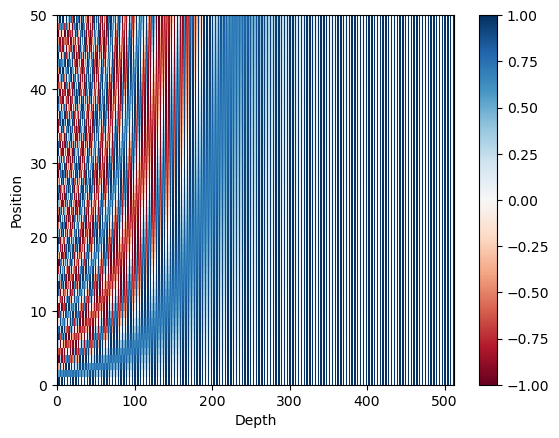

In [ ]:
# 產生一個長度 50、維度 512 的位置編碼矩陣
pos_encoding = positional_encoding(50, 512)

# 印出 Positional Encoding 的 shape → 應為 (1, 50, 512)
print(pos_encoding.shape)

# 使用 matplotlib 將 Positional Encoding 矩陣可視化
# 取出 batch 維度 (只取 pos_encoding[0]，shape: (50, 512))

plt.pcolormesh(pos_encoding[0], cmap='RdBu')  # 使用 pcolormesh 繪製 2D 色彩網格圖
plt.xlabel('Depth')     # X 軸標示：embedding 維度
plt.xlim((0, 512))      # 限制 x 軸範圍到 512 維
plt.ylabel('Position')  # Y 軸標示：句子中的 token 位置
plt.colorbar()          # 顯示右側色條，方便觀察數值大小
plt.show()


## Masking

Mask all the pad tokens in the batch of sequence. It ensures that the model does not treat padding as the input. The mask indicates where pad value `0` is present: it outputs a `1` at those locations, and a `0` otherwise.

In [ ]:
# 建立 Padding Mask
# 主要用在 Encoder 與 Decoder 中，避免模型在 attention 計算時看到 padding 位置

def create_padding_mask(seq):
    # 先把序列中等於 0 (padding token) 的位置標記出來
    # tf.math.equal(seq, 0) → 會產生 True/False tensor
    # tf.cast(..., tf.float32) → 轉成 0.0 或 1.0（方便後續計算遮罩）
    seq = tf.cast(tf.math.equal(seq, 0), tf.float32)

    # 擴展維度，方便與 attention logits 做 broadcast 相容
    # 原始 shape: (batch_size, seq_len)
    # 轉換後 shape: (batch_size, 1, 1, seq_len)
    # 這樣可直接套用到 scaled dot-product attention 的 logits 上
    return seq[:, tf.newaxis, tf.newaxis, :]


In [ ]:
# 建立一個小型範例序列 (batch_size=3, seq_len=5)
# 其中 0 代表 padding 位置

x = tf.constant([
    [7, 6, 0, 0, 1],  # 第 1 筆資料中間有 padding (兩個 0)
    [1, 2, 3, 0, 0],  # 第 2 筆資料最後有 padding (兩個 0)
    [0, 0, 0, 4, 5]   # 第 3 筆資料前面有 padding (三個 0)
])

# 呼叫剛剛寫好的 create_padding_mask() 產生 padding mask
mask = create_padding_mask(x)

# 顯示結果
mask


<tf.Tensor: shape=(3, 1, 1, 5), dtype=float32, numpy=
array([[[[0., 0., 1., 1., 0.]]],


       [[[0., 0., 0., 1., 1.]]],


       [[[1., 1., 1., 0., 0.]]]], dtype=float32)>

The look-ahead mask is used to mask the future tokens in a sequence. In other words, the mask indicates which entries should not be used.

This means that to predict the third word, only the first and second word will be used. Similarly to predict the fourth word, only the first, second and the third word will be used and so on.

In [ ]:
# 建立 Look-Ahead Mask（遮蔽未來 token，防止偷看）
# 用在 Decoder 的 Self-Attention 裡，讓模型只能看到目前與過去的資訊

def create_look_ahead_mask(size):
    """
    size: 序列長度 (seq_len)
    輸出: shape 為 (seq_len, seq_len) 的遮罩矩陣
    """

    # tf.ones((size, size)) 先建立全 1 的方陣
    # tf.linalg.band_part() 用來保留下三角部分
    #   -1: 下三角無限制
    #    0: 只保留對角線與下三角
    lower_triangle = tf.linalg.band_part(tf.ones((size, size)), -1, 0)

    # 1 - lower_triangle → 變成上三角 (strict upper triangle)
    # 上三角部分會是 1 (遮蔽)，下三角部分會是 0 (可見)
    mask = 1 - lower_triangle

    return mask  # (seq_len, seq_len)


In [ ]:
# 建立一個隨機的輸入 tensor，shape 為 (1, 3)
# 這裡只是假資料，主要目的是取得序列長度 size
x = tf.random.uniform((1, 3))

# 取得序列長度：x.shape[1] → 3
# 也就是序列長度 size = 3
temp = create_look_ahead_mask(x.shape[1])

# 查看產生的 look-ahead mask
temp


<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]], dtype=float32)>

## Scaled dot product attention

<img src="https://www.tensorflow.org/images/tutorials/transformer/scaled_attention.png" width="500" alt="scaled_dot_product_attention">

The attention function used by the transformer takes three inputs: Q (query), K (key), V (value). The equation used to calculate the attention weights is:

$$\Large{Attention(Q, K, V) = softmax_k(\frac{QK^T}{\sqrt{d_k}}) V} $$

The dot-product attention is scaled by a factor of square root of the depth. This is done because for large values of depth, the dot product grows large in magnitude pushing the softmax function where it has small gradients resulting in a very hard softmax.

For example, consider that `Q` and `K` have a mean of 0 and variance of 1. Their matrix multiplication will have a mean of 0 and variance of `dk`. Hence, *square root of `dk`* is used for scaling (and not any other number) because the matmul of `Q` and `K` should have a mean of 0 and variance of 1, and you get a gentler softmax.

The mask is multiplied with -1e9 (close to negative infinity). This is done because the mask is summed with the scaled matrix multiplication of Q and K and is applied immediately before a softmax. The goal is to zero out these cells, and large negative inputs to softmax are near zero in the output.

In [ ]:
# 定義 Scaled Dot-Product Attention 函式
# 這是 Transformer 裡面所有 attention block 最核心的運算

def scaled_dot_product_attention(q, k, v, mask):
    """
    計算注意力權重與輸出

    參數說明：
    q: query 向量，shape == (..., seq_len_q, depth)
    k: key 向量，shape == (..., seq_len_k, depth)
    v: value 向量，shape == (..., seq_len_v, depth_v)
    mask: 遮罩 (padding mask or look-ahead mask)，可為 None

    回傳：
    output: 注意力加權後的 value 輸出，shape == (..., seq_len_q, depth_v)
    attention_weights: softmax 注意力權重，shape == (..., seq_len_q, seq_len_k)
    """

    # 先計算 Q 和 K 的點積 (dot-product)
    # 這裡轉置 K → 讓 inner product 正確計算
    matmul_qk = tf.matmul(q, k, transpose_b=True)  # shape: (..., seq_len_q, seq_len_k)

    # 進行 scaling 動作：將 dot-product 結果除以 √depth，避免梯度消失或爆炸
    dk = tf.cast(tf.shape(k)[-1], tf.float32)  # depth (通常等於 embedding 維度除以 head 數)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

    # 如果有遮罩，將遮罩套用到 logits 上（遮罩位置加上 -1e9 讓 softmax 輸出趨近於 0）
    if mask is not None:
        scaled_attention_logits += (mask * -1e9)

    # 在最後一個維度 (seq_len_k) 做 softmax，得到每個 key 對 query 的注意力權重
    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # shape: (..., seq_len_q, seq_len_k)

    # 計算 attention 輸出：用注意力權重對 value 做加權平均
    output = tf.matmul(attention_weights, v)  # shape: (..., seq_len_q, depth_v)

    return output, attention_weights


As the softmax normalization is done on K, its values decide the amount of importance given to Q.

The output represents the multiplication of the attention weights and the V (value) vector. This ensures that the words you want to focus on are kept as-is and the irrelevant words are flushed out.

In [ ]:
# 定義一個輔助函式，方便我們觀察 Scaled Dot-Product Attention 的內部輸出

def print_out(q, k, v):
    # 呼叫剛剛寫好的 scaled_dot_product_attention() 函式
    # 此處不套用任何遮罩 (mask=None)
    temp_out, temp_attn = scaled_dot_product_attention(q, k, v, None)

    # 印出注意力權重矩陣
    print('Attention weights are:')
    print(temp_attn)

    # 印出注意力加權輸出結果
    print('Output is:')
    print(temp_out)


In [ ]:
# 建立一組小型 Q/K/V tensor 來測試：
np.set_printoptions(suppress=True)

q = tf.constant([[1, 0, 0]], dtype=tf.float32)  # shape (1, 3)
k = tf.constant([[1, 0, 0],
                 [0, 1, 0],
                 [0, 0, 1]], dtype=tf.float32)  # shape (3, 3)
v = tf.constant([[10, 0],
                 [0, 10],
                 [0, 0]], dtype=tf.float32)  # shape (3, 2)

print_out(q, k, v)


Attention weights are:
tf.Tensor([[0. 1. 0. 0.]], shape=(1, 4), dtype=float32)
Output is:
tf.Tensor([[10.  0.]], shape=(1, 2), dtype=float32)


In [ ]:
# 這個 query 向量設計成與 key 的第三與第四個向量方向對齊（即重複 key）
# 因此注意力會將與這兩個 key 對應的 value 做加權平均

# 定義 query（Q），shape: (1, 3)
# 這裡假設第 3 維 (index 2) 非零 → 會與 K 的某些方向高對齊
temp_q = tf.constant([[0, 0, 10]], dtype=tf.float32)

# 呼叫前面寫好的 print_out() 來觀察 attention 運算結果
print_out(temp_q, temp_k, temp_v)


Attention weights are:
tf.Tensor([[0.  0.  0.5 0.5]], shape=(1, 4), dtype=float32)
Output is:
tf.Tensor([[550.    5.5]], shape=(1, 2), dtype=float32)


In [ ]:
# 這個 query 設計成同時與第一個與第二個 key 對齊
# 觀察當 query 與多個 key 同時對齊時，注意力如何平均其對應的 value

# 定義 query（Q），shape: (1, 3)
# 這次強調第一、第二維 (index 0 與 index 1) 對齊
temp_q = tf.constant([[10, 10, 0]], dtype=tf.float32)

# 呼叫前面寫好的 print_out() 來觀察注意力計算結果
print_out(temp_q, temp_k, temp_v)


Attention weights are:
tf.Tensor([[0.5 0.5 0.  0. ]], shape=(1, 4), dtype=float32)
Output is:
tf.Tensor([[5.5 0. ]], shape=(1, 2), dtype=float32)


Pass all the queries together.

In [ ]:
# 定義多組 query，一次處理多筆資料 (batch_size = 3, seq_len_q = 3)

# 第一個 query: [0, 0, 10] → 強烈對齊第三個 key (測試對齊單一 key)
# 第二個 query: [0, 10, 0] → 強烈對齊第二個 key (測試對齊單一 key)
# 第三個 query: [10, 10, 0] → 同時對齊第一與第二個 key (測試平均融合行為)

temp_q = tf.constant([
    [0, 0, 10],
    [0, 10, 0],
    [10, 10, 0]
], dtype=tf.float32)  # shape: (3, 3)

# 呼叫前面寫好的 print_out()，觀察多組 query 一次 attention 運算的結果
print_out(temp_q, temp_k, temp_v)


Attention weights are:
tf.Tensor(
[[0.  0.  0.5 0.5]
 [0.  1.  0.  0. ]
 [0.5 0.5 0.  0. ]], shape=(3, 4), dtype=float32)
Output is:
tf.Tensor(
[[550.    5.5]
 [ 10.    0. ]
 [  5.5   0. ]], shape=(3, 2), dtype=float32)


## Multi-head attention

<img src="https://www.tensorflow.org/images/tutorials/transformer/multi_head_attention.png" width="500" alt="multi-head attention">


Multi-head attention consists of four parts:
*    Linear layers and split into heads.
*    Scaled dot-product attention.
*    Concatenation of heads.
*    Final linear layer.

Each multi-head attention block gets three inputs; Q (query), K (key), V (value). These are put through linear (Dense) layers and split up into multiple heads.

The `scaled_dot_product_attention` defined above is applied to each head (broadcasted for efficiency). An appropriate mask must be used in the attention step.  The attention output for each head is then concatenated (using `tf.transpose`, and `tf.reshape`) and put through a final `Dense` layer.

Instead of one single attention head, Q, K, and V are split into multiple heads because it allows the model to jointly attend to information at different positions from different representational spaces. After the split each head has a reduced dimensionality, so the total computation cost is the same as a single head attention with full dimensionality.

In [ ]:
# 定義 Multi-Head Attention 層 (完整 Keras 版本)
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()

        self.num_heads = num_heads  # 頭數（幾個獨立的注意力子空間）
        self.d_model = d_model      # 整體 embedding 維度

        # 檢查 d_model 是否可整除 num_heads
        assert d_model % self.num_heads == 0

        # 每個 head 裡面注意力空間的維度
        self.depth = d_model // self.num_heads

        # 建立三個線性投影層：分別將輸入轉換成 Query、Key、Value
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)

        # 結合所有 head 之後的最終線性層
        self.dense = tf.keras.layers.Dense(d_model)

    # 將最後一維拆成 (num_heads, depth)，並做轉置方便做 attention 計算
    def split_heads(self, x, batch_size):
        """
        將輸入轉成 (batch_size, num_heads, seq_len, depth)
        """
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    # 核心運算流程 (v, k, q, mask)
    def call(self, v, k, q, mask):
        batch_size = tf.shape(q)[0]

        # 先將 q, k, v 分別通過線性層
        q = self.wq(q)  # (batch_size, seq_len, d_model)
        k = self.wk(k)  # (batch_size, seq_len, d_model)
        v = self.wv(v)  # (batch_size, seq_len, d_model)

        # 再拆成多頭格式
        q = self.split_heads(q, batch_size)  # (batch_size, num_heads, seq_len_q, depth)
        k = self.split_heads(k, batch_size)  # (batch_size, num_heads, seq_len_k, depth)
        v = self.split_heads(v, batch_size)  # (batch_size, num_heads, seq_len_v, depth)

        # 計算 scaled dot-product attention
        scaled_attention, attention_weights = scaled_dot_product_attention(q, k, v, mask)
        # scaled_attention: (batch_size, num_heads, seq_len_q, depth)

        # 將注意力輸出轉回 (batch_size, seq_len_q, num_heads, depth)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

        # 合併所有 heads
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))  # (batch_size, seq_len_q, d_model)

        # 最後再接一個線性層，回到原始 embedding space
        output = self.dense(concat_attention)  # (batch_size, seq_len_q, d_model)

        return output, attention_weights


Create a `MultiHeadAttention` layer to try out. At each location in the sequence, `y`, the `MultiHeadAttention` runs all 8 attention heads across all other locations in the sequence, returning a new vector of the same length at each location.

In [ ]:
# 建立一個 MultiHeadAttention 物件
# d_model=512：整體 embedding 維度
# num_heads=8：使用 8 個 attention head
temp_mha = MultiHeadAttention(d_model=512, num_heads=8)

# 建立一組隨機測試輸入 (模擬 encoder 輸出)
# shape: (batch_size=1, sequence_length=60, d_model=512)
y = tf.random.uniform((1, 60, 512))

# 呼叫 multi-head attention 模型
# 這裡模擬自注意力 (self-attention)，所以 q=k=v=y
# 沒有遮罩 (mask=None)
out, attn = temp_mha(y, k=y, q=y, mask=None)

# 輸出兩個 shape：
# out.shape: (batch_size, seq_len, d_model)
# attn.shape: (batch_size, num_heads, seq_len, seq_len)
out.shape, attn.shape


(TensorShape([1, 60, 512]), TensorShape([1, 8, 60, 60]))

## Point wise feed forward network

Point wise feed forward network consists of two fully-connected layers with a ReLU activation in between.

In [ ]:
# 定義 Position-wise Feed Forward Network
# 這是 Transformer Encoder/Decoder Block 裡面每個 layer 的第二部分（Attention 後的 FFN）

def point_wise_feed_forward_network(d_model, dff):
    """
    d_model: 輸入與輸出維度（通常等於 embedding 維度）
    dff: 隱藏層中間擴充的維度（通常為 d_model 的 2~4 倍）

    回傳：一個 Keras Sequential 模型，包含兩層 Dense 全連接層
    """

    return tf.keras.Sequential([
        # 第一層：擴展維度 → 非線性變換 (使用 ReLU 激活)
        tf.keras.layers.Dense(dff, activation='relu'),  # shape: (batch_size, seq_len, dff)

        # 第二層：壓回原始 d_model 維度
        tf.keras.layers.Dense(d_model)  # shape: (batch_size, seq_len, d_model)
    ])


In [ ]:
# 建立一個具體的 Feed Forward Network 實例
# d_model = 512 (輸入與輸出維度)
# dff = 2048 (中間擴充維度，通常設定成 4 倍擴展)
sample_ffn = point_wise_feed_forward_network(512, 2048)

# 建立一個隨機輸入 tensor，模擬 (batch_size=64, seq_len=50, d_model=512)
dummy_input = tf.random.uniform((64, 50, 512))

# 將隨機輸入送入 FFN 做前向運算，並檢查輸出 shape
sample_ffn(dummy_input).shape


TensorShape([64, 50, 512])

## Encoder and decoder

<img src="https://www.tensorflow.org/images/tutorials/transformer/transformer.png" width="600" alt="transformer">

### Encoder layer

Each encoder layer consists of sublayers:

1.   Multi-head attention (with padding mask)
2.    Point wise feed forward networks.

Each of these sublayers has a residual connection around it followed by a layer normalization. Residual connections help in avoiding the vanishing gradient problem in deep networks.

The output of each sublayer is `LayerNorm(x + Sublayer(x))`. The normalization is done on the `d_model` (last) axis. There are N encoder layers in the transformer.

In [ ]:
# 定義 Transformer Encoder Layer
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(EncoderLayer, self).__init__()

        # 多頭注意力模組
        self.mha = MultiHeadAttention(d_model, num_heads)

        # 前饋神經網路 (Feed Forward Network)
        self.ffn = point_wise_feed_forward_network(d_model, dff)

        # Layer Normalization，epsilon 防止除零錯誤
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        # Dropout 正則化，避免 overfitting
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training, mask):
        # ===== Multi-Head Attention 子層 =====
        # Self-Attention: Q=K=V=x
        attn_output, _ = self.mha(x, x, x, mask)  # shape: (batch_size, seq_len, d_model)

        # Dropout 防止 overfitting（訓練中才啟用）
        attn_output = self.dropout1(attn_output, training=training)

        # 殘差連接 + LayerNorm
        out1 = self.layernorm1(x + attn_output)

        # ===== Feed Forward 子層 =====
        ffn_output = self.ffn(out1)  # shape: (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output, training=training)

        # 殘差連接 + LayerNorm
        out2 = self.layernorm2(out1 + ffn_output)

        return out2


In [ ]:
# 建立一個 Encoder Layer 實例
# 參數與 Transformer 標準設計一致：
# d_model = 512（embedding 維度）
# num_heads = 8（8 個 attention head）
# dff = 2048（前饋層的隱藏維度，通常取 4 倍 d_model）
sample_encoder_layer = EncoderLayer(512, 8, 2048)

# 建立一組模擬的輸入資料
# batch_size = 64，序列長度 = 43，embedding 維度 = 512
dummy_input = tf.random.uniform((64, 43, 512))

# 將測試資料輸入 Encoder Layer，執行 forward pass
# 這裡設 training=False (推論模式)，暫不套用 dropout
# mask=None（暫時不加任何 padding mask）
sample_encoder_layer_output = sample_encoder_layer(
    x=dummy_input, training=False, mask=None)

# 查看 Encoder Layer 輸出 shape
sample_encoder_layer_output.shape  # 預期為 (batch_size, input_seq_len, d_model)


TensorShape([64, 43, 512])

### Decoder layer

Each decoder layer consists of sublayers:

1.   Masked multi-head attention (with look ahead mask and padding mask)
2.   Multi-head attention (with padding mask). V (value) and K (key) receive the *encoder output* as inputs. Q (query) receives the *output from the masked multi-head attention sublayer.*
3.   Point wise feed forward networks

Each of these sublayers has a residual connection around it followed by a layer normalization. The output of each sublayer is `LayerNorm(x + Sublayer(x))`. The normalization is done on the `d_model` (last) axis.

There are N decoder layers in the transformer.

As Q receives the output from decoder's first attention block, and K receives the encoder output, the attention weights represent the importance given to the decoder's input based on the encoder's output. In other words, the decoder predicts the next word by looking at the encoder output and self-attending to its own output. See the demonstration above in the scaled dot product attention section.

In [ ]:
# 定義 Transformer Decoder Layer
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(DecoderLayer, self).__init__()

        # 第一層 Multi-Head Attention (Masked Self-Attention)
        self.mha1 = MultiHeadAttention(d_model, num_heads)

        # 第二層 Multi-Head Attention (Encoder-Decoder Attention)
        self.mha2 = MultiHeadAttention(d_model, num_heads)

        # Feed Forward 子層
        self.ffn = point_wise_feed_forward_network(d_model, dff)

        # Layer Normalization 與 Dropout (共三個殘差分支)
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)
        self.dropout3 = tf.keras.layers.Dropout(rate)

    # forward function
    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        # enc_output.shape == (batch_size, input_seq_len, d_model)

        # ====== 第一個注意力子層：Masked Multi-Head Self-Attention ======
        attn1, attn_weights_block1 = self.mha1(
            x, x, x, look_ahead_mask)  # (batch_size, target_seq_len, d_model)

        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(attn1 + x)  # 殘差 + LayerNorm

        # ====== 第二個注意力子層：Encoder-Decoder Attention ======
        attn2, attn_weights_block2 = self.mha2(
            enc_output, enc_output, out1, padding_mask)  # Q=out1, K/V=enc_output

        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(attn2 + out1)  # 殘差 + LayerNorm

        # ====== Feed Forward 子層 ======
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.layernorm3(ffn_output + out2)  # 殘差 + LayerNorm

        # 回傳 Decoder 輸出與兩層注意力權重
        return out3, attn_weights_block1, attn_weights_block2


In [ ]:
# 建立一個 Decoder Layer 實例
# d_model = 512（embedding 維度）
# num_heads = 8（8 個 attention head）
# dff = 2048（前饋層的隱藏維度）
sample_decoder_layer = DecoderLayer(512, 8, 2048)

# 建立一組模擬的 target 輸入序列 (假裝已經過 embedding 與 positional encoding)
# batch_size = 64，target_seq_len = 50，embedding 維度 = 512
dummy_target_input = tf.random.uniform((64, 50, 512))

# 使用先前 Encoder Layer 測試得到的 sample_encoder_layer_output 作為 encoder 輸出
# 呼叫 Decoder Layer 進行 forward pass
# training=False（推論模式不啟用 dropout）
# look_ahead_mask=None（暫時不套用 look-ahead 遮罩）
# padding_mask=None（暫時不套用 padding 遮罩）
sample_decoder_layer_output, _, _ = sample_decoder_layer(
    dummy_target_input,                  # decoder input (target sequence embedding)
    sample_encoder_layer_output,         # encoder output
    training=False,
    look_ahead_mask=None,
    padding_mask=None
)

# 查看 Decoder Layer 輸出 shape
sample_decoder_layer_output.shape  # 預期為 (batch_size, target_seq_len, d_model)


TensorShape([64, 50, 512])

### Encoder

The `Encoder` consists of:
1.   Input Embedding
2.   Positional Encoding
3.   N encoder layers

The input is put through an embedding which is summed with the positional encoding. The output of this summation is the input to the encoder layers. The output of the encoder is the input to the decoder.

In [ ]:
# 定義完整 Encoder 架構 (包含多層 EncoderLayer 疊加)
class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
                 maximum_position_encoding, rate=0.1):
        super(Encoder, self).__init__()

        self.d_model = d_model
        self.num_layers = num_layers  # 疊加層數

        # 詞嵌入 (word embedding)
        self.embedding = tf.keras.layers.Embedding(input_vocab_size, d_model)

        # 位置編碼 (positional encoding)，事先計算好最大長度的編碼表
        self.pos_encoding = positional_encoding(maximum_position_encoding, self.d_model)

        # 建立 num_layers 個 EncoderLayer 疊加成 stack
        self.enc_layers = [
            EncoderLayer(d_model, num_heads, dff, rate)
            for _ in range(num_layers)
        ]

        # Dropout (訓練正則化)
        self.dropout = tf.keras.layers.Dropout(rate)

    # forward pass
    def call(self, x, training, mask):
        seq_len = tf.shape(x)[1]  # 目前批次的實際序列長度

        # 先做詞嵌入 (embedding lookup)
        x = self.embedding(x)  # shape: (batch_size, input_seq_len, d_model)

        # 對 embedding 做 scaling，穩定訓練 (√d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))

        # 加上位置編碼 (broadcast 位置維度到 seq_len)
        x += self.pos_encoding[:, :seq_len, :]

        # dropout (訓練中才啟用)
        x = self.dropout(x, training=training)

        # 疊加多層 EncoderLayer
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)

        return x  # shape: (batch_size, input_seq_len, d_model)


In [ ]:
# 建立一個完整 Encoder 物件
sample_encoder = Encoder(
    num_layers=2,               # 疊加 2 層 EncoderLayer
    d_model=512,                # embedding 維度 512
    num_heads=8,                # 8 個 attention head
    dff=2048,                   # feedforward hidden size 為 2048
    input_vocab_size=8500,      # 詞彙表大小 8500
    maximum_position_encoding=10000  # 預設支援最大序列長度 10000
)

# 建立一組模擬的輸入資料 (注意：這裡還是 token index，不是 embedding)
# batch_size = 64，序列長度 = 62，每個 token index 取值範圍為 [0, 200)
temp_input = tf.random.uniform(
    (64, 62), dtype=tf.int64, minval=0, maxval=200)

# 呼叫 Encoder，執行 forward pass
sample_encoder_output = sample_encoder(
    x=temp_input,
    training=False,  # 模擬推論模式
    mask=None        # 暫時不套用 padding mask
)

# 查看 Encoder 輸出 shape
print(sample_encoder_output.shape)
# 預期輸出為 (batch_size, input_seq_len, d_model) → (64, 62, 512)


(64, 62, 512)


### Decoder

 The `Decoder` consists of:
1.   Output Embedding
2.   Positional Encoding
3.   N decoder layers

The target is put through an embedding which is summed with the positional encoding. The output of this summation is the input to the decoder layers. The output of the decoder is the input to the final linear layer.

In [ ]:
# 定義完整 Transformer Decoder Stack
class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size,
                 maximum_position_encoding, rate=0.1):
        super(Decoder, self).__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        # 詞嵌入層 (word embedding for target language)
        self.embedding = tf.keras.layers.Embedding(target_vocab_size, d_model)

        # 位置編碼 (與 Encoder 相同邏輯)
        self.pos_encoding = positional_encoding(maximum_position_encoding, d_model)

        # 疊加多層 DecoderLayer
        self.dec_layers = [
            DecoderLayer(d_model, num_heads, dff, rate)
            for _ in range(num_layers)
        ]

        # Dropout (正則化)
        self.dropout = tf.keras.layers.Dropout(rate)

    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        seq_len = tf.shape(x)[1]

        # 紀錄各層的注意力權重，方便後續可視化分析
        attention_weights = {}

        # 詞嵌入
        x = self.embedding(x)  # (batch_size, target_seq_len, d_model)

        # Embedding scaling
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))

        # 加入位置編碼
        x += self.pos_encoding[:, :seq_len, :]

        # Dropout
        x = self.dropout(x, training=training)

        # 疊加多層 DecoderLayer
        for i in range(self.num_layers):
            x, block1, block2 = self.dec_layers[i](
                x, enc_output, training=training,
                look_ahead_mask=look_ahead_mask,
                padding_mask=padding_mask)

            # 記錄每層 attention 權重 (方便可視化或 debug)
            attention_weights[f'decoder_layer{i+1}_block1'] = block1  # masked self-attention
            attention_weights[f'decoder_layer{i+1}_block2'] = block2  # encoder-decoder attention

        # 最後輸出：
        # x: (batch_size, target_seq_len, d_model)
        # attention_weights: 各層注意力權重
        return x, attention_weights


In [ ]:
# 建立完整 Decoder 物件
sample_decoder = Decoder(
    num_layers=2,               # 疊加 2 層 DecoderLayer
    d_model=512,                # embedding 維度 512
    num_heads=8,                # 8 個 attention head
    dff=2048,                   # feedforward 隱藏層 2048
    target_vocab_size=8000,     # target 詞彙表大小
    maximum_position_encoding=5000  # 最大支援序列長度
)

# 建立模擬 target 輸入 (這裡輸入的是 token index，不是 embedding)
# batch_size = 64，target_seq_len = 26
temp_input = tf.random.uniform(
    (64, 26), dtype=tf.int64, minval=0, maxval=200)

# 執行 Decoder forward pass，將 Encoder 輸出餵進來
output, attn = sample_decoder(
    temp_input,
    enc_output=sample_encoder_output,  # 來自前面 Encoder 測試的輸出
    training=False,                    # 推論模式 (不啟用 dropout)
    look_ahead_mask=None,              # 暫不使用遮罩
    padding_mask=None                  # 暫不使用 padding mask
)

# 查看 Decoder 輸出與注意力 shape
output.shape, attn['decoder_layer2_block2'].shape


(TensorShape([64, 26, 512]), TensorShape([64, 8, 26, 62]))

## Create the Transformer

Transformer consists of the encoder, decoder and a final linear layer. The output of the decoder is the input to the linear layer and its output is returned.

In [ ]:
# 定義完整 Transformer 模型（Encoder + Decoder 全架構組合）
class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
                 target_vocab_size, pe_input, pe_target, rate=0.1):
        super(Transformer, self).__init__()

        # Encoder：編碼 source 句子
        self.encoder = Encoder(
            num_layers, d_model, num_heads, dff,
            input_vocab_size, pe_input, rate)

        # Decoder：解碼 target 句子
        self.decoder = Decoder(
            num_layers, d_model, num_heads, dff,
            target_vocab_size, pe_target, rate)

        # 最後線性層，投影到 target vocab 空間 (logits for softmax)
        self.final_layer = tf.keras.layers.Dense(target_vocab_size)

    # 模型 forward pass
    def call(self, inp, tar, training, enc_padding_mask,
             look_ahead_mask, dec_padding_mask):
        # Encoder 輸出：shape (batch_size, inp_seq_len, d_model)
        enc_output = self.encoder(
            inp, training=training, mask=enc_padding_mask)

        # Decoder 輸出：shape (batch_size, tar_seq_len, d_model)
        dec_output, attention_weights = self.decoder(
            tar, enc_output, training=training,
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask)

        # 最後全連接層：投影到 target vocab 空間
        final_output = self.final_layer(dec_output)
        # shape: (batch_size, tar_seq_len, target_vocab_size)

        return final_output, attention_weights


In [ ]:
# 建立完整 Transformer 模型物件
sample_transformer = Transformer(
    num_layers=2,          # 疊加 2 層 Encoder/Decoder Layer
    d_model=512,           # embedding 維度 512
    num_heads=8,           # 8 個 attention head
    dff=2048,              # feedforward hidden size 2048
    input_vocab_size=8500, # source vocab size 8500
    target_vocab_size=8000,# target vocab size 8000
    pe_input=10000,        # 位置編碼長度 (source)
    pe_target=6000         # 位置編碼長度 (target)
)

# 產生模擬測試資料：
# temp_input：模擬 source input 序列 (batch_size=64, input_seq_len=38)
temp_input = tf.random.uniform(
    (64, 38), dtype=tf.int64, minval=0, maxval=200)

# temp_target：模擬 target 序列 (batch_size=64, target_seq_len=36)
temp_target = tf.random.uniform(
    (64, 36), dtype=tf.int64, minval=0, maxval=200)

# 將模擬資料送入 Transformer 做 forward pass
# 暫時不加任何遮罩（但實際訓練會需要遮罩）
fn_out, _ = sample_transformer(
    temp_input, temp_target,
    training=False,
    enc_padding_mask=None,
    look_ahead_mask=None,
    dec_padding_mask=None
)

# 確認 Transformer 輸出 shape
fn_out.shape  # 預期為 (batch_size, target_seq_len, target_vocab_size)


TensorShape([64, 36, 8000])

## Set hyperparameters

To keep this example small and relatively fast, the values for *num_layers, d_model, and dff* have been reduced.

The values used in the base model of transformer were; *num_layers=6*, *d_model = 512*, *dff = 2048*. See the [paper](https://arxiv.org/abs/1706.03762) for all the other versions of the transformer.

Note: By changing the values below, you can get the model that achieved state of the art on many tasks.

In [ ]:
# Transformer 模型參數設定 (實際訓練用)
num_layers = 6   # 疊加 6 層 Encoder / Decoder Layer（標準論文設定）
d_model = 512    # embedding 維度 512
dff = 2048       # 前饋神經網路隱藏層維度 2048（通常取 d_model 的 4 倍）
num_heads = 8    # Multi-Head Attention 的頭數（每個 head 維度為 512/8=64）

# 取得實際 vocab size：
# 注意：要加 2，因為 tokenizer 中額外包含 <start> 和 <end> 符號
input_vocab_size = tokenizer_pt.vocab_size + 2   # 葡萄牙文詞彙表大小
target_vocab_size = tokenizer_en.vocab_size + 2  # 英文詞彙表大小

# Dropout 機率，避免 overfitting
dropout_rate = 0.1


## Optimizer

Use the Adam optimizer with a custom learning rate scheduler according to the formula in the [paper](https://arxiv.org/abs/1706.03762).

$$\Large{lrate = d_{model}^{-0.5} * min(step{\_}num^{-0.5}, step{\_}num * warmup{\_}steps^{-1.5})}$$


In [ ]:
# 自定義學習率調度器 (Transformer 論文所使用的 Learning Rate Schedule)
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super(CustomSchedule, self).__init__()

        self.d_model = d_model
        self.d_model = tf.cast(self.d_model, tf.float32)  # 確保使用 float32 計算
        self.warmup_steps = warmup_steps  # 預熱步數

    def __call__(self, step):
        step = tf.cast(step, tf.float32)  # 保證浮點運算

        # 按論文公式計算學習率
        arg1 = tf.math.rsqrt(step)                    # 1 / sqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)     # step / (warmup_steps^(3/2))

        # 最後學習率公式：
        # lr = d_model^{-0.5} * min(step^{-0.5}, step * warmup_steps^{-1.5})
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)


In [ ]:
# 建立學習率調度器 (使用剛剛實作的 CustomSchedule)
learning_rate = CustomSchedule(d_model)

# 建立 Adam 優化器 (符合 Transformer 論文中的設定)
optimizer = tf.keras.optimizers.Adam(
    learning_rate,        # 使用自定義學習率調度
    beta_1=0.9,           # 一階動量（與標準 Adam 相同）
    beta_2=0.98,          # 二階動量（比標準 Adam 稍低，與論文一致）
    epsilon=1e-9          # 防止除零錯誤，較小 epsilon 提高穩定性
)


Text(0.5, 0, 'Train Step')

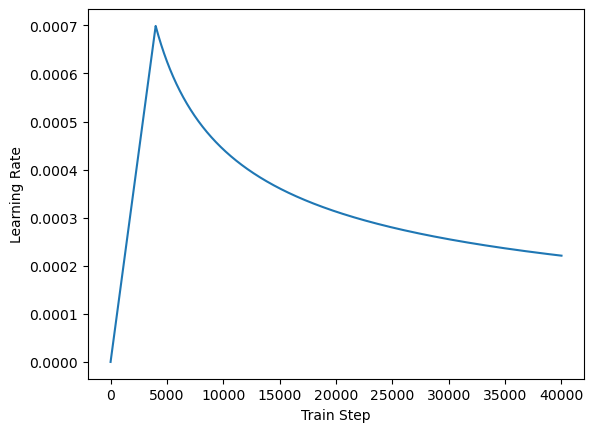

In [ ]:
# 建立學習率排程物件 (使用前面實作的 CustomSchedule)
temp_learning_rate_schedule = CustomSchedule(d_model)

# 產生 0 ~ 40000 個訓練步數 (注意是浮點數，確保型別一致)
train_steps = tf.range(40000, dtype=tf.float32)

# 計算每個步數下的學習率
learning_rates = temp_learning_rate_schedule(train_steps)

# 畫出學習率變化曲線
plt.plot(learning_rates)
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")
plt.title("Transformer Learning Rate Schedule (Noam Scheduler)")
plt.show()


## Loss and metrics

Since the target sequences are padded, it is important to apply a padding mask when calculating the loss.

In [ ]:
# 定義損失函數
# 這裡使用 Sparse Categorical Crossentropy（因為 target 是整數 token index，不是 one-hot）
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,  # 因為模型最後輸出尚未經過 softmax（logits）
    reduction='none'   # 不自動對 batch 內的樣本做平均 → 方便之後套用 mask
)


In [ ]:
# 定義帶有 mask 的 loss function
def loss_function(real, pred):
    # 產生 mask → 將 real 中 padding (token == 0) 的部分遮蔽掉
    mask = tf.math.logical_not(tf.math.equal(real, 0))

    # 計算所有位置的 cross-entropy loss
    loss_ = loss_object(real, pred)

    # 將布林 mask 轉換成與 loss 相同 dtype (float32)
    mask = tf.cast(mask, dtype=loss_.dtype)

    # 將 padding 位置的 loss 設為 0（只保留非 padding 位置的 loss）
    loss_ *= mask

    # 最後計算 masked average loss
    return tf.reduce_sum(loss_) / tf.reduce_sum(mask)


In [ ]:
# 建立訓練過程中的損失 (Loss) 監控指標
train_loss = tf.keras.metrics.Mean(name='train_loss')
# → 用來追蹤每個 batch 訓練 loss 的移動平均

# 建立訓練過程中的準確率 (Accuracy) 監控指標
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')
# → 用來計算每個 batch 訓練準確率 (target 是整數 token ID，所以用 SparseCategoricalAccuracy)


## Training and checkpointing

In [ ]:
# 初始化完整 Transformer 模型

transformer = Transformer(
    num_layers,            # Encoder/Decoder 疊加層數 (前面你設定為 6)
    d_model,               # Embedding 維度 (512)
    num_heads,             # Multi-Head Attention 頭數 (8)
    dff,                   # FeedForward 隱藏層維度 (2048)
    input_vocab_size,      # 輸入端 (source) 詞彙表大小 (tokenizer_pt.vocab_size + 2)
    target_vocab_size,     # 輸出端 (target) 詞彙表大小 (tokenizer_en.vocab_size + 2)
    pe_input=input_vocab_size,   # 最大位置編碼長度 (輸入端)
    pe_target=target_vocab_size, # 最大位置編碼長度 (輸出端)
    rate=dropout_rate      # Dropout 機率 (0.1)
)


In [ ]:
# 建立所有訓練所需的三個 mask：
# - Encoder padding mask
# - Decoder look ahead mask (self-attention)
# - Decoder padding mask (encoder-decoder attention)

def create_masks(inp, tar):
    # Encoder padding mask
    # 用來遮蔽 encoder 輸入中的 padding 位置 (token==0)
    enc_padding_mask = create_padding_mask(inp)

    # Decoder 中的 encoder-decoder attention 也需要同樣的 padding mask
    # 因為 decoder 會去 attend encoder 輸出 (encoder output 的 padding 也需遮蔽)
    dec_padding_mask = create_padding_mask(inp)

    # Decoder 中 self-attention 要加 look-ahead mask (prevent cheating)
    look_ahead_mask = create_look_ahead_mask(tf.shape(tar)[1])

    # 同時要遮蔽 target 中 padding 位置
    dec_target_padding_mask = create_padding_mask(tar)

    # 將 look-ahead 與 target padding mask 結合：
    # - max(0, 1) 表示如果任一個位置需要遮蔽則遮蔽
    combined_mask = tf.maximum(dec_target_padding_mask, look_ahead_mask)

    return enc_padding_mask, combined_mask, dec_padding_mask


Create the checkpoint path and the checkpoint manager. This will be used to save checkpoints every `n` epochs.

In [ ]:
# 設定檢查點儲存路徑
checkpoint_path = "./checkpoints/train"

# 建立檢查點物件，追蹤 Transformer 模型與 Optimizer 狀態
ckpt = tf.train.Checkpoint(
    transformer=transformer,
    optimizer=optimizer
)

# 建立檢查點管理器，最多保留最近 5 個檔案
ckpt_manager = tf.train.CheckpointManager(
    ckpt, checkpoint_path, max_to_keep=5
)

# 若存在先前的檢查點，載入最新的模型與 optimizer 狀態
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    print('Latest checkpoint restored!!')


In [ ]:
# 設定訓練總迭代輪數
EPOCHS = 20


In [ ]:
# 定義 train_step 函數的輸入簽名，規定輸入是任意 batch size、任意序列長度的 int64 tensor
train_step_signature = [
    tf.TensorSpec(shape=(None, None), dtype=tf.int64),  # inp (source sequences)
    tf.TensorSpec(shape=(None, None), dtype=tf.int64),  # tar (target sequences)
]

# 使用 tf.function 讓 train_step 被轉換成 TensorFlow 計算圖，提升效能
@tf.function(input_signature=train_step_signature)
def train_step(inp, tar):
    # Decoder 輸入：去掉 target 序列最後一個 token (teacher forcing)
    tar_inp = tar[:, :-1]

    # Decoder 真實目標：去掉 target 序列第一個 token
    tar_real = tar[:, 1:]

    # 建立 Encoder 和 Decoder 的遮罩
    enc_padding_mask, combined_mask, dec_padding_mask = create_masks(inp, tar_inp)

    # 計算梯度與損失
    with tf.GradientTape() as tape:
        predictions, _ = transformer(
            inp,
            tar_inp,
            training=True,
            enc_padding_mask=enc_padding_mask,
            look_ahead_mask=combined_mask,
            dec_padding_mask=dec_padding_mask
        )
        loss = loss_function(tar_real, predictions)

    # 計算梯度
    gradients = tape.gradient(loss, transformer.trainable_variables)

    # 利用 optimizer 更新模型參數
    optimizer.apply_gradients(zip(gradients, transformer.trainable_variables))

    # 更新訓練損失與準確率指標
    train_loss(loss)
    train_accuracy(tar_real, predictions)


Portuguese is used as the input language and English is the target language.

In [ ]:
for epoch in range(EPOCHS):
    start = time.time()  # 紀錄 epoch 開始時間

    # 重置監控指標，準備新一輪統計
    train_loss.reset_state()
    train_accuracy.reset_state()

    # 迭代訓練資料集的每個 batch
    # inp 是 source 語言 (葡萄牙文)
    # tar 是 target 語言 (英文)
    for (batch, (inp, tar)) in enumerate(train_dataset):
        # 執行單步訓練
        train_step(inp, tar)

        # 每 50 個 batch 輸出一次訓練狀態
        if batch % 50 == 0:
            print('Epoch {} Batch {} Loss {:.4f} Accuracy {:.4f}'.format(
                epoch + 1,
                batch,
                train_loss.result(),
                train_accuracy.result()
            ))

    # 每 5 個 epoch 保存一次模型檢查點
    if (epoch + 1) % 5 == 0:
        ckpt_save_path = ckpt_manager.save()
        print('Saving checkpoint for epoch {} at {}'.format(epoch + 1, ckpt_save_path))

    # 輸出本 epoch 結束的整體訓練損失與準確率
    print('Epoch {} Loss {:.4f} Accuracy {:.4f}'.format(
        epoch + 1,
        train_loss.result(),
        train_accuracy.result()
    ))

    # 輸出本 epoch 花費時間
    print('Time taken for 1 epoch: {} secs\n'.format(time.time() - start))


Epoch 1 Batch 0 Loss 9.0796 Accuracy 0.0004
Epoch 1 Batch 50 Loss 8.7691 Accuracy 0.0161
Epoch 1 Batch 100 Loss 8.4772 Accuracy 0.0212
Epoch 1 Batch 150 Loss 8.2415 Accuracy 0.0242
Epoch 1 Batch 200 Loss 7.9803 Accuracy 0.0301
Epoch 1 Batch 250 Loss 7.7122 Accuracy 0.0363
Epoch 1 Batch 300 Loss 7.4789 Accuracy 0.0413
Epoch 1 Batch 350 Loss 7.2922 Accuracy 0.0452
Epoch 1 Batch 400 Loss 7.1379 Accuracy 0.0488
Epoch 1 Batch 450 Loss 7.0039 Accuracy 0.0529
Epoch 1 Batch 500 Loss 6.8781 Accuracy 0.0573
Epoch 1 Batch 550 Loss 6.7597 Accuracy 0.0618
Epoch 1 Batch 600 Loss 6.6460 Accuracy 0.0661
Epoch 1 Batch 650 Loss 6.5402 Accuracy 0.0702
Epoch 1 Batch 700 Loss 6.4397 Accuracy 0.0740
Epoch 1 Loss 6.4362 Accuracy 0.0741
Time taken for 1 epoch: 203.79801321029663 secs

Epoch 2 Batch 0 Loss 5.1818 Accuracy 0.1322
Epoch 2 Batch 50 Loss 5.0512 Accuracy 0.1262
Epoch 2 Batch 100 Loss 5.0068 Accuracy 0.1283
Epoch 2 Batch 150 Loss 4.9668 Accuracy 0.1304
Epoch 2 Batch 200 Loss 4.9420 Accuracy 0.1322
E

## Evaluate

The following steps are used for evaluation:

* Encode the input sentence using the Portuguese tokenizer (`tokenizer_pt`). Moreover, add the start and end token so the input is equivalent to what the model is trained with. This is the encoder input.
* The decoder input is the `start token == tokenizer_en.vocab_size`.
* Calculate the padding masks and the look ahead masks.
* The `decoder` then outputs the predictions by looking at the `encoder output` and its own output (self-attention).
* Select the last word and calculate the argmax of that.
* Concatentate the predicted word to the decoder input as pass it to the decoder.
* In this approach, the decoder predicts the next word based on the previous words it predicted.

Note: The model used here has less capacity to keep the example relatively faster so the predictions maybe less right. To reproduce the results in the paper, use the entire dataset and base transformer model or transformer XL, by changing the hyperparameters above.

In [ ]:
def evaluate(inp_sentence):
    # 定義起始與結束 token id（根據 tokenizer 詞彙表大小）
    start_token = [tokenizer_pt.vocab_size]
    end_token = [tokenizer_pt.vocab_size + 1]

    # 將輸入句子 (葡萄牙文) 轉成 token id 並加上起訖 token
    inp_sentence = start_token + tokenizer_pt.encode(inp_sentence) + end_token
    # 加 batch 維度 (batch_size=1)
    encoder_input = tf.expand_dims(inp_sentence, 0)

    # Decoder 初始輸入為英文起始 token
    decoder_input = [tokenizer_en.vocab_size]
    output = tf.expand_dims(decoder_input, 0)

    # 最多產生 MAX_LENGTH 個詞彙
    for i in range(MAX_LENGTH):
        # 建立 Encoder 與 Decoder 的遮罩
        enc_padding_mask, combined_mask, dec_padding_mask = create_masks(
            encoder_input, output)

        # 透過 Transformer 預測下一個詞彙的機率分布
        # predictions shape = (batch_size=1, seq_len, target_vocab_size)
        predictions, attention_weights = transformer(
            encoder_input,
            output,
            training=False,
            enc_padding_mask=enc_padding_mask,
            look_ahead_mask=combined_mask,
            dec_padding_mask=dec_padding_mask)

        # 取出序列最後一個位置的預測（最新產生的詞彙）
        predictions = predictions[:, -1:, :]  # (1, 1, target_vocab_size)

        # 取得預測機率最高的詞彙 id
        predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)

        # 若預測為結束 token，結束解碼並回傳結果
        if predicted_id == tokenizer_en.vocab_size + 1:
            return tf.squeeze(output, axis=0), attention_weights

        # 否則將預測的詞彙 id 拼接到 output，作為下一輪 decoder 輸入
        output = tf.concat([output, predicted_id], axis=-1)

    # 若未遇結束 token，則回傳當前結果（超長解碼）
    return tf.squeeze(output, axis=0), attention_weights


In [ ]:
def plot_attention_weights(attention, sentence, result, layer):
    # 建立一個大圖版面，大小為 16x8 英吋
    fig = plt.figure(figsize=(16, 8))

    # 將輸入句子 (葡萄牙文) 轉成 token ID 序列
    sentence = tokenizer_pt.encode(sentence)

    # 去除 batch 維度，取得該層注意力權重 tensor
    # shape: (num_heads, target_seq_len, input_seq_len)
    attention = tf.squeeze(attention[layer], axis=0)

    # 針對每個 attention head 分別繪圖
    for head in range(attention.shape[0]):
        ax = fig.add_subplot(2, 4, head + 1)  # 8 個 head，排成 2x4 格局

        # 繪製注意力權重矩陣（去掉最後一行）
        ax.matshow(attention[head][:-1, :], cmap='viridis')

        fontdict = {'fontsize': 10}

        # 設定 x 軸 ticks，包含起始與結束 token
        ax.set_xticks(range(len(sentence) + 2))
        # 設定 y 軸 ticks
        ax.set_yticks(range(len(result)))

        # 調整 y 軸顯示範圍，使圖看起來方向正常
        ax.set_ylim(len(result) - 1.5, -0.5)

        # x 軸標籤為原文 token，含 <start> 和 <end>
        ax.set_xticklabels(
            ['<start>'] + [tokenizer_pt.decode([i]) for i in sentence] + ['<end>'],
            fontdict=fontdict, rotation=90)

        # y 軸標籤為預測結果的英文 token
        ax.set_yticklabels([tokenizer_en.decode([i]) for i in result], fontdict=fontdict)

        # x 軸標題標示目前是哪個 head
        ax.set_xlabel(f'Head {head + 1}')

    # 調整整體版面避免重疊
    plt.tight_layout()
    plt.show()


In [ ]:
def translate(sentence, plot=''):
    # 呼叫 evaluate() 做自回歸解碼，獲得翻譯結果與注意力權重
    result, attention_weights = evaluate(sentence)

    # 將預測序列中的 token id 解碼回英文句子（去除特殊詞彙 <start>, <end>）
    predicted_sentence = tokenizer_en.decode([
        i for i in result if i < tokenizer_en.vocab_size
    ])

    # 輸出原始輸入句子
    print('Input: {}'.format(sentence))

    # 輸出模型預測翻譯句子
    print('Predicted translation: {}'.format(predicted_sentence))

    # 若指定 plot 參數，繪製注意力權重熱力圖
    if plot:
        plot_attention_weights(attention_weights, sentence, result, plot)


In [ ]:
# 使用自定義的 translate 函數對葡萄牙文句子做英文翻譯
translate("este é um problema que temos que resolver.")

# 印出這句的正確翻譯，方便與模型預測結果比較
print("Real translation: this is a problem we have to solve .")


Input: este é um problema que temos que resolver.
Predicted translation: this is a problem that we have all of us all .
Real translation: this is a problem we have to solve .


In [ ]:
# 使用自定義的 translate 函數對葡萄牙文句子做英文翻譯
translate("os meus vizinhos ouviram sobre esta ideia.")
# 印出這句的正確翻譯，方便與模型預測結果比較
print ("Real translation: and my neighboring homes heard about this idea .")

Input: os meus vizinhos ouviram sobre esta ideia.
Predicted translation: my male talk to you know this happened about javas .
Real translation: and my neighboring homes heard about this idea .


In [ ]:
# 使用自定義的 translate 函數對葡萄牙文句子做英文翻譯
translate("vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.")
# 印出這句的正確翻譯，方便與模型預測結果比較
print ("Real translation: so i 'll just share with you some stories very quickly of some magical things that have happened .")

Input: vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.
Predicted translation: so i 'd like to share some of those things with you very short things that had very little .
Real translation: so i 'll just share with you some stories very quickly of some magical things that have happened .


You can pass different layers and attention blocks of the decoder to the `plot` parameter.

In [ ]:
def plot_attention_weights(attention, sentence, result, layer):
    # 建立大圖版面，大小16x8英吋
    fig = plt.figure(figsize=(16, 8))

    # 將輸入句子編碼成 token id 序列
    sentence = tokenizer_pt.encode(sentence)
    # 去除 batch 維度，取得該層注意力權重，shape: (num_heads, target_seq_len, input_seq_len)
    attention = tf.squeeze(attention[layer], axis=0)

    # 針對每個 attention head 畫子圖
    for head in range(attention.shape[0]):
        ax = fig.add_subplot(2, 4, head + 1)
        # 繪製注意力矩陣熱力圖 (去除 decoder 最後一個位置)
        ax.matshow(attention[head][:-1, :], cmap='viridis')

        fontdict = {'fontsize': 10}

        # 設定 x 軸 ticks 與標籤，包含 <start> 和 <end> token
        ax.set_xticks(range(len(sentence) + 2))
        ax.set_xticklabels(
            ['<start>'] + [tokenizer_pt.decode([i]) for i in sentence] + ['<end>'],
            fontdict=fontdict, rotation=90)

        # 只篩選合法的 token id (小於詞彙表大小)
        valid_tokens = [i for i in result if i < tokenizer_en.vocab_size]
        ax.set_yticks(range(len(valid_tokens)))
        # y 軸標籤為英文翻譯的 token
        ax.set_yticklabels([tokenizer_en.decode([i]) for i in valid_tokens], fontdict=fontdict)

        # 調整 y 軸顯示範圍使方向正確
        ax.set_ylim(len(valid_tokens) - 1.5, -0.5)
        ax.set_xlabel(f'Head {head + 1}')

    # 美化整體版面
    plt.tight_layout()
    plt.show()


Input: este é o primeiro livro que eu fiz.
Predicted translation: this is the first picture i had was in nomber .


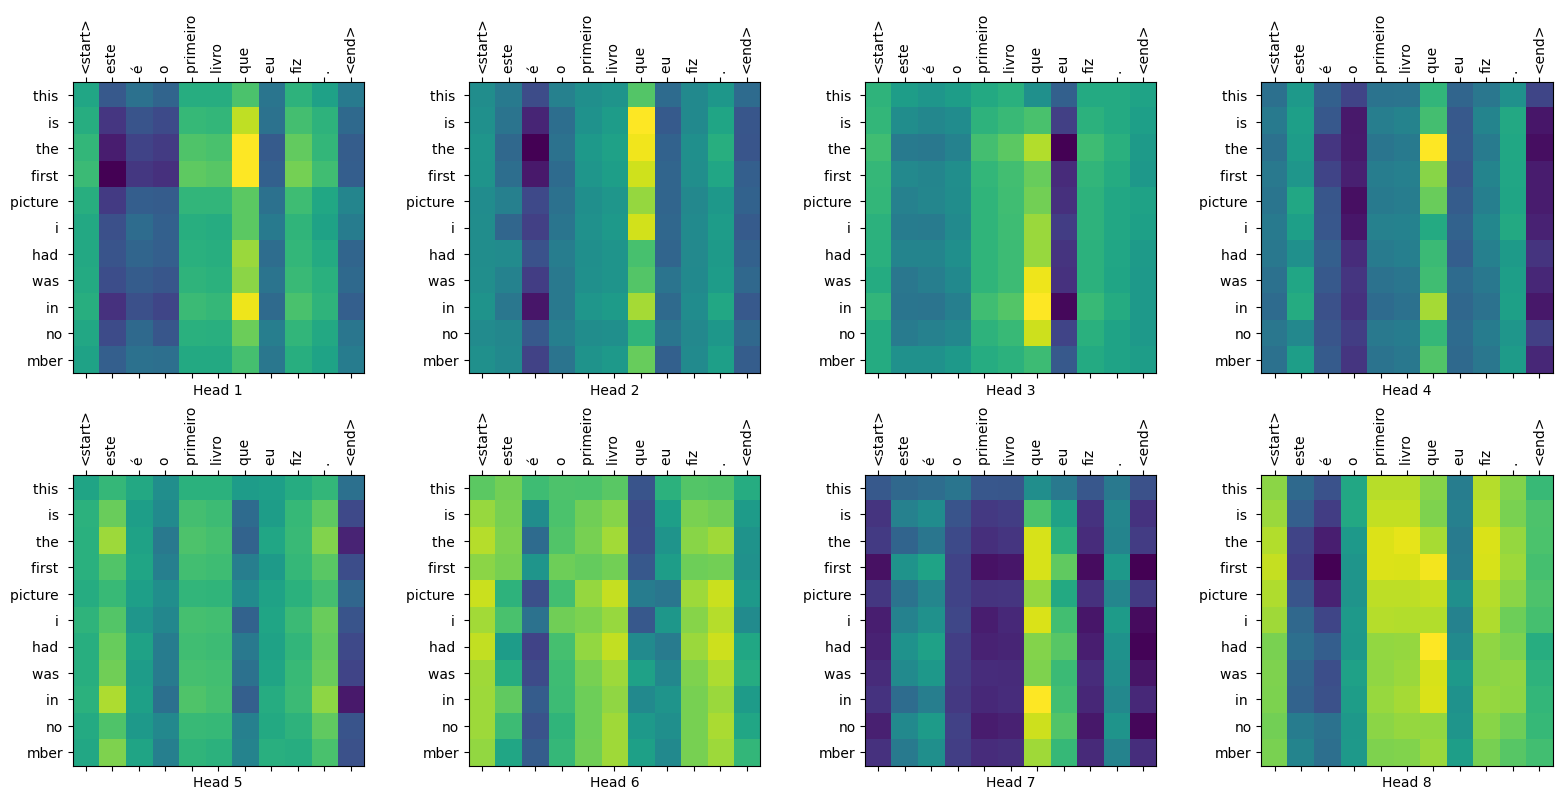

Real translation: this is the first book i've ever done.


In [ ]:
# 呼叫自定義的 translate 函數翻譯葡萄牙文句子
# 並且繪製 decoder 第4層第二個注意力機制 (encoder-decoder attention) 的熱力圖
translate("este é o primeiro livro que eu fiz.", plot='decoder_layer4_block2')

# 印出該句子的正確英文翻譯，方便與模型預測結果比較
print("Real translation: this is the first book i've ever done.")


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# 參考正確翻譯句子，拆成詞的列表
reference = "this is the first book i've ever done .".split()

# 機器翻譯候選句子，拆成詞的列表
candidate  = "this is the first picture i had was in nomber .".split()

# 計算 BLEU-4 分數，四個 n-gram 權重均等 (0.25)
# 使用 method3 平滑，避免單句 BLEU 分數直接為 0（特別是短句）
score = sentence_bleu(
    [reference],               # 參考句，必須是 list of lists
    candidate,                # 預測句
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=SmoothingFunction().method3
)

# 印出 BLEU-4 分數，四位小數
print(f"BLEU‑4 (含平滑) = {score:.4f}")


BLEU‑4 (含平滑) = 0.2481
